# Gestão de Riscos Geopolíticos em Ativos de Commodities — B3
**Disciplina:** Inteligência de Mercado e Analytics  
**Autora:** Gabriela Alvim De Nigris  
**Data:** Junho de 2026  

---

**Pergunta central:** Como choques geopolíticos internacionais alteram a volatilidade diária e o Value at Risk de uma carteira de commodities na B3?

**Ativos analisados:**
| Ticker | Empresa | Commodity |
|--------|---------|-----------|
| VALE3.SA | Vale S.A. | Minério de ferro / Níquel |
| PETR4.SA | Petrobras PN | Petróleo / Gás |
| PRIO3.SA | PetroRio | Petróleo (E&P offshore) |
| GGBR4.SA | Gerdau PN | Aço / Sucata |

**Metodologia:** Análise gráfica de séries temporais · Matrizes de covariância sob estresse · VaR Histórico e Paramétrico a 95%

---

### Linha do tempo dos eventos geopolíticos cobertos

| Data | Evento | Canal de transmissão |
|------|--------|----------------------|
| 24/02/2022 | Invasão russa à Ucrânia | Choque de commodities agrícolas e energéticas; Risco global |
| 07/10/2023 | Conflito Israel–Hamas | Prêmio de risco de guerra no petróleo; risco regional |
| 02/04/2025 | Tarifas Trump — "Liberation Day" | Guerra comercial global; colapso de ativos de risco |
| 20/02/2026 | Ultimato nuclear de Trump ao Irã | Petróleo dispara; risco de fechamento do Estreito de Hormuz |
| 28/02/2026 | Ataques EUA–Israel contra o Irã | Hormuz bloqueado; petróleo tem maior alta em 4 anos |
| 06/04/2026 | Ultimato sobre reabertura de Hormuz | WTI acima de US$ 115; escalada máxima do conflito |
| Mai/2026 | Negociações de cessar-fogo | Petróleo recua ~20% dos picos; alívio parcial |


## 1. Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3
plt.rcParams['font.size']      = 11


## 2. Coleta de Dados — Yahoo Finance

Coleta de preços de fechamento ajustados de **Janeiro/2022 a Junho/2026**, cobrindo integralmente os principais choques geopolíticos do período, incluindo o conflito EUA–Irã de 2026.


In [2]:
# definição dos ativos e período de análise
ATIVOS   = ['VALE3.SA', 'PETR4.SA', 'PRIO3.SA', 'GGBR4.SA']
NOMES    = {'VALE3.SA': 'Vale', 'PETR4.SA': 'Petrobras', 'PRIO3.SA': 'PetroRio', 'GGBR4.SA': 'Gerdau'}
DATA_INI = '2022-01-01'
DATA_FIM = '2026-06-04'   # até hoje

# download dos preços de fechamento ajustados
df_precos = yf.download(ATIVOS, start=DATA_INI, end=DATA_FIM, auto_adjust=True, progress=False)['Close']
df_precos.columns.name = None
df_precos.index.name   = 'Data'
df_precos = df_precos.rename(columns=NOMES)

print(f"Período: {df_precos.index[0].date()} → {df_precos.index[-1].date()}")
print(f"Observações: {len(df_precos)} dias úteis")
print(f"Dados ausentes por ativo:\n{df_precos.isnull().sum()}")
df_precos.tail()


Período: 2022-01-03 → 2026-06-03
Observações: 1103 dias úteis
Dados ausentes por ativo:
Gerdau       0
Petrobras    0
PetroRio     0
Vale         0
dtype: int64


,Gerdau,Petrobras,PetroRio,Vale
Data,,,,
2026-05-28,23.500000,41.806709,62.970001,83.959999
2026-05-29,22.770000,41.305149,62.250000,82.820000
2026-06-01,23.139999,41.669025,62.820000,81.699997
2026-06-02,24.650000,41.570000,61.980000,85.000000
2026-06-03,24.129999,41.250000,62.590000,81.790001


## 3. Análise da Série Temporal de Preços

Visualização dos preços normalizados (base 100 = jan/2022) para comparação direta entre ativos.  
**Normalização:** $P_t^{norm} = 100 \times P_t / P_0$

Os marcadores identificam os momentos de maior impacto geopolítico documentado no período.


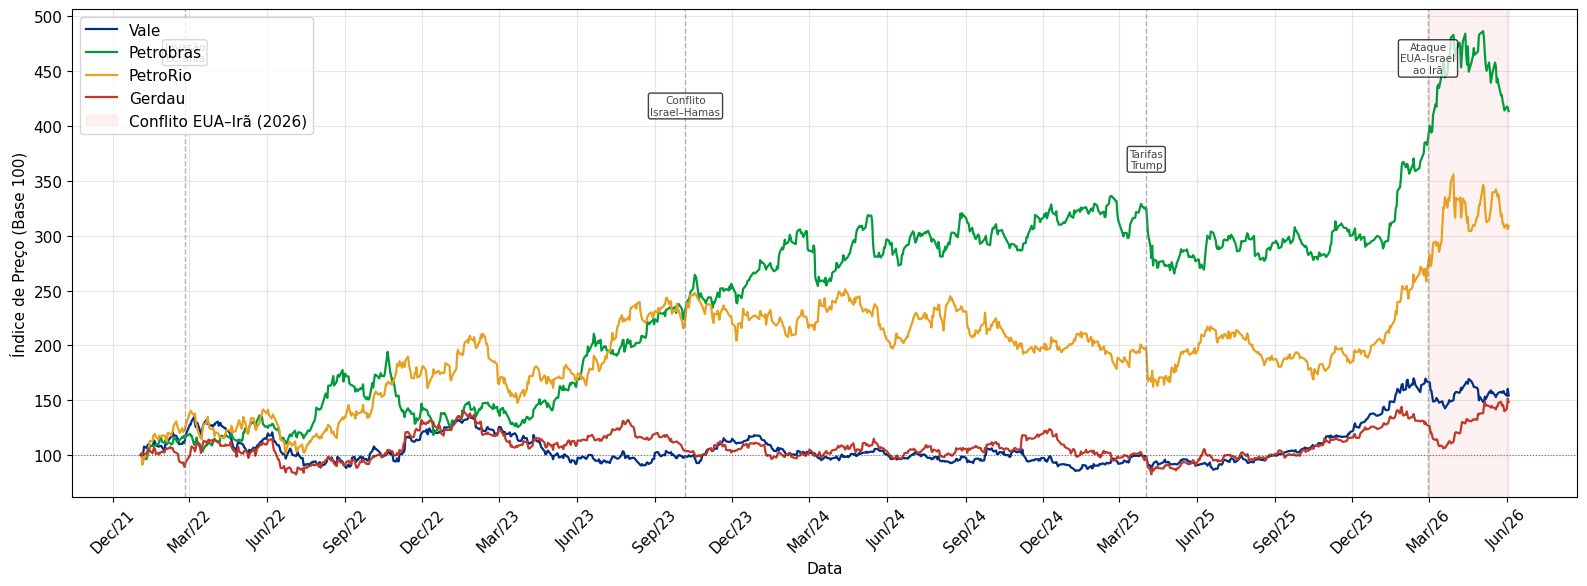

In [5]:
# eventos geopolíticos — data de impacto central no mercado
EVENTOS = {
    'Invasão\nUcrânia': '2022-02-24',
    'Conflito\nIsrael–Hamas': '2023-10-07',
    'Tarifas\nTrump': '2025-04-02',
    'Ataque\nEUA–Israel\nao Irã': '2026-02-28',
}

# normalizar preços na base 100
df_norm = df_precos / df_precos.iloc[0] * 100

cores = {'Vale': '#003087', 'Petrobras': '#009c3b', 'PetroRio': '#e8a020', 'Gerdau': '#c0392b'}

fig, ax = plt.subplots(figsize=(16, 6))

for ativo, cor in cores.items():
    ax.plot(df_norm.index, df_norm[ativo], label=ativo, color=cor, linewidth=1.6)

# marcadores de eventos — alternar altura para evitar sobreposição de rótulos
alturas = [0.98, 0.88, 0.78, 0.98, 0.88, 0.78]
for (nome, data), alt in zip(EVENTOS.items(), alturas):
    data_dt = pd.to_datetime(data)
    if data_dt <= df_norm.index[-1]:
        ax.axvline(data_dt, color='gray', linestyle='--', alpha=0.6, linewidth=1)
        ymax = df_norm.max().max()
        ax.text(data_dt, ymax * alt, nome,
                fontsize=7.5, ha='center', va='top', color='#444',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75))

# faixa sombreada: período do conflito EUA–Irã (fev–jun/2026)
ax.axvspan(pd.to_datetime('2026-02-28'), df_norm.index[-1],
           color='#e74c3c', alpha=0.07, label='Conflito EUA–Irã (2026)')

ax.axhline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Data')
ax.set_ylabel('Índice de Preço (Base 100)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Retornos Diários e Volatilidade

**Cálculo do retorno logarítmico diário:**  
$r_t = \ln(P_t / P_{t-1})$

Retornos logarítmicos são preferidos em finanças quantitativas por garantirem aditividade temporal e simetria na distribuição.


In [8]:
# cálculo dos retornos logarítmicos diários
retornos = np.log(df_precos / df_precos.shift(1)).dropna()

# estatísticas descritivas
print("=== ESTATÍSTICAS DESCRITIVAS DOS RETORNOS DIÁRIOS ===\n")
stats = retornos.describe().T
stats['skewness'] = retornos.skew()
stats['kurtosis'] = retornos.kurtosis()
print(stats[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']].round(5))


=== ESTATÍSTICAS DESCRITIVAS DOS RETORNOS DIÁRIOS ===

              mean      std      min      max  skewness  kurtosis
Gerdau     0.00036  0.01961 -0.08264  0.09176   0.12805   1.73458
Petrobras  0.00129  0.01964 -0.09650  0.07684  -0.51041   2.84382
PetroRio   0.00102  0.02372 -0.11387  0.08640  -0.17565   1.76303
Vale       0.00039  0.01805 -0.06894  0.09890   0.35730   2.21872


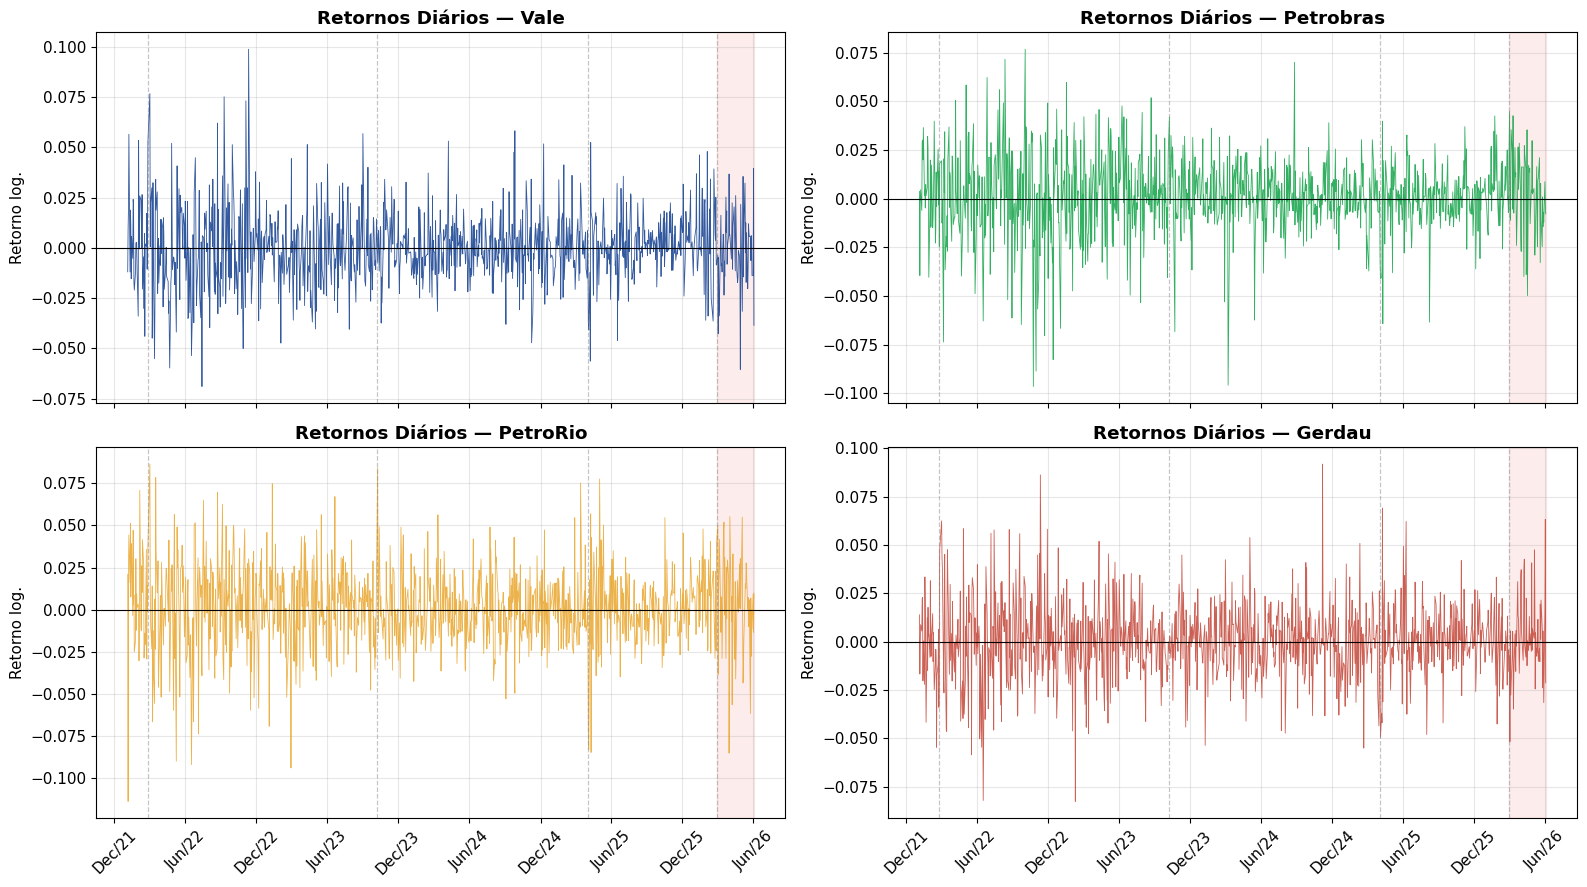

In [10]:
# gráfico dos retornos diários — subplots por ativo
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for i, (ativo, cor) in enumerate(cores.items()):
    ax = axes[i]
    ax.plot(retornos.index, retornos[ativo], color=cor, linewidth=0.6, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)

    # faixa do conflito EUA–Irã
    ax.axvspan(pd.to_datetime('2026-02-28'), retornos.index[-1],
               color='#e74c3c', alpha=0.10)

    for nome, data in EVENTOS.items():
        dt = pd.to_datetime(data)
        if dt <= retornos.index[-1]:
            ax.axvline(dt, color='gray', linestyle='--', alpha=0.45, linewidth=0.9)

    ax.set_title(f'Retornos Diários — {ativo}', fontweight='bold')
    ax.set_ylabel('Retorno log.')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


## 5. Volatilidade Móvel Anualizada (Rolling Volatility)

**Janela de 21 dias úteis** (~1 mês). O fator $\sqrt{252}$ anualiza a estimativa.

$\sigma_t^{(21)} = \sqrt{\frac{1}{21}\sum_{i=0}^{20}(r_{t-i} - \bar{r})^2} \times \sqrt{252}$

Picos de volatilidade coincidem com os choques geopolíticos identificados. O período do conflito EUA–Irã (fev–jun/2026) deve evidenciar os maiores picos para Petrobras e PetroRio, dado seu maior grau de exposição ao preço do petróleo.


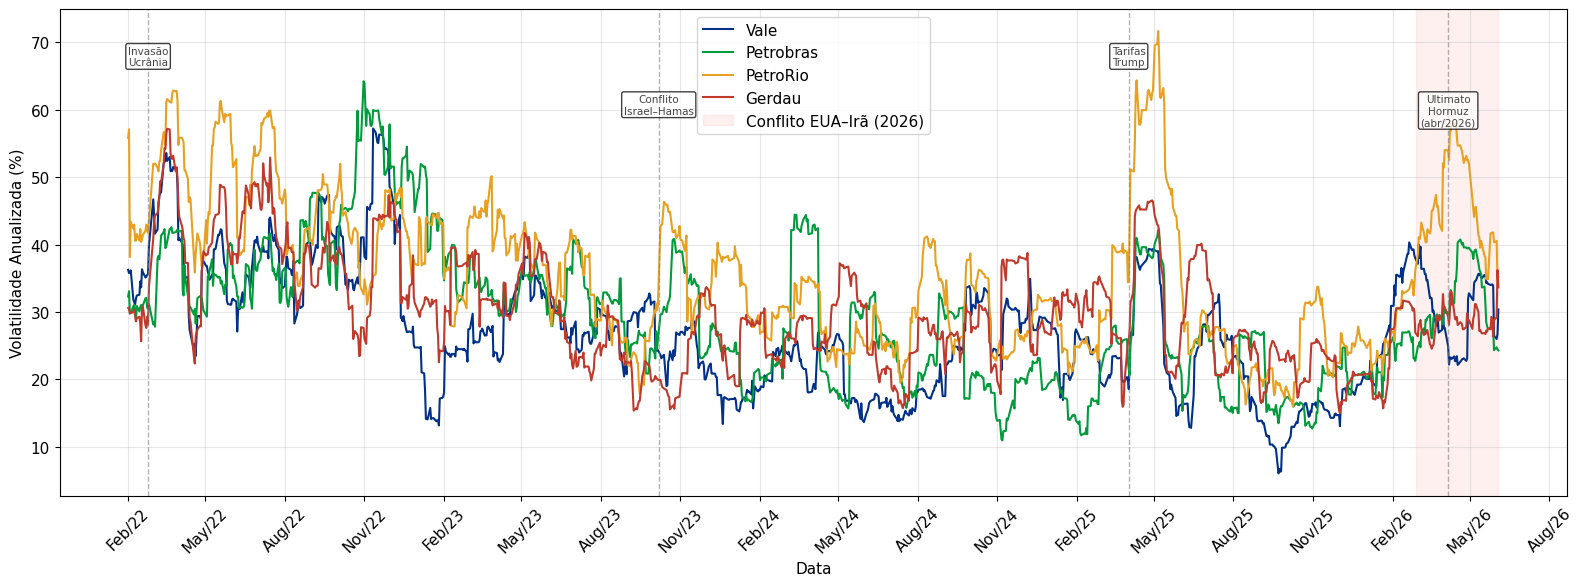

In [11]:
# volatilidade móvel anualizada (janela de 21 dias úteis)
vol_movel = retornos.rolling(window=21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(16, 6))

for ativo, cor in cores.items():
    ax.plot(vol_movel.index, vol_movel[ativo] * 100, label=ativo, color=cor, linewidth=1.5)

# faixa sombreada: conflito EUA–Irã
ax.axvspan(pd.to_datetime('2026-02-28'), vol_movel.index[-1],
           color='#e74c3c', alpha=0.08, label='Conflito EUA–Irã (2026)')

# marcadores de eventos (sem os dois de 2026 que ficam dentro da faixa)
EVENTOS_LINHAS = {
    'Invasão\nUcrânia': '2022-02-24',
    'Conflito\nIsrael–Hamas': '2023-10-07',
    'Tarifas\nTrump': '2025-04-02',
    'Ultimato\nHormuz\n(abr/2026)': '2026-04-06',
}

alturas_vol = [0.97, 0.87, 0.97, 0.87]
for (nome, data), alt in zip(EVENTOS_LINHAS.items(), alturas_vol):
    dt = pd.to_datetime(data)
    if dt <= vol_movel.index[-1]:
        ax.axvline(dt, color='gray', linestyle='--', alpha=0.6, linewidth=1)
        ymax = (vol_movel * 100).max().max()
        ax.text(dt, ymax * alt, nome, fontsize=7.5, ha='center', va='top',
                color='#444', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75))

ax.set_xlabel('Data')
ax.set_ylabel('Volatilidade Anualizada (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Matrizes de Correlação — Período Normal vs. Conflito EUA–Irã (2026)

Comparação entre a matriz de correlação em período de tranquilidade relativa e durante o pico do conflito EUA–Irã.

- **Período normal:** Julho a Dezembro de 2024
- **Período de estresse (Irã):** 28 de fevereiro a 4 de junho de 2026

O aumento das correlações sob estresse geopolítico reduz os benefícios da diversificação — fenômeno conhecido como **"correlation breakdown"** ou contágio.


Obs. período normal:             127 dias
Obs. período conflito EUA–Irã:   65 dias


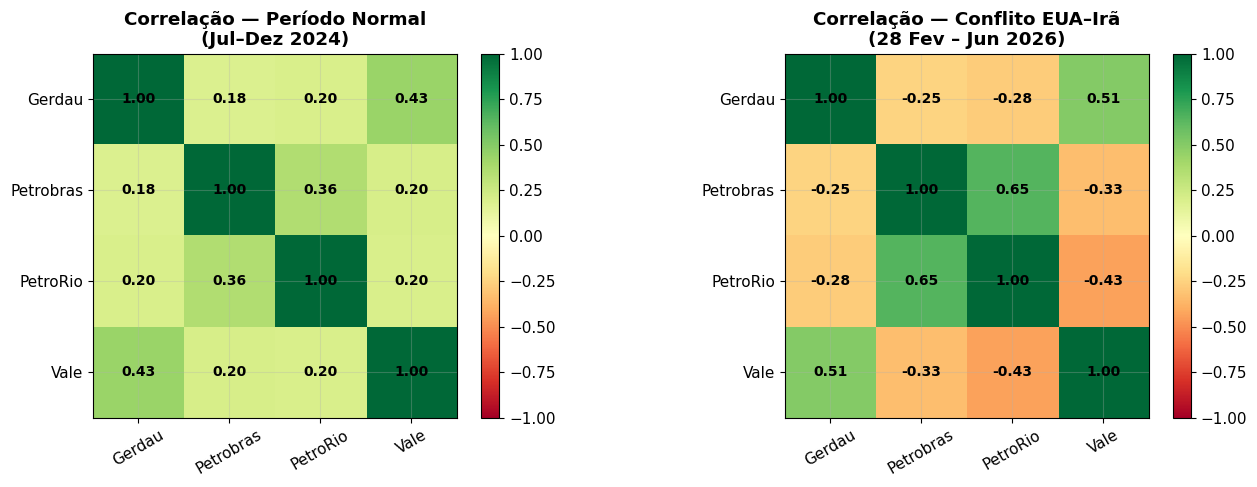


=== COVARIÂNCIA — PERÍODO NORMAL (anualizada) ===
             Gerdau  Petrobras  PetroRio      Vale
Gerdau     0.080039   0.011027  0.017356  0.031185
Petrobras  0.011027   0.046153  0.023578  0.011202
PetroRio   0.017356   0.023578  0.093714  0.015261
Vale       0.031185   0.011202  0.015261  0.064857

=== COVARIÂNCIA — CONFLITO EUA–IRÃ (anualizada) ===
             Gerdau  Petrobras  PetroRio      Vale
Gerdau     0.107341  -0.026936 -0.041113  0.050389
Petrobras -0.026936   0.108213  0.097030 -0.032814
PetroRio  -0.041113   0.097030  0.207410 -0.059657
Vale       0.050389  -0.032814 -0.059657  0.091898


In [12]:
# definir janelas de análise
periodo_normal   = retornos['2024-07-01':'2024-12-31']
periodo_estresse = retornos['2026-02-28':]   # conflito EUA–Irã

cov_normal   = periodo_normal.cov()   * 252   # anualizada
cov_estresse = periodo_estresse.cov() * 252

corr_normal   = periodo_normal.corr()
corr_estresse = periodo_estresse.corr()

print(f"Obs. período normal:             {len(periodo_normal)} dias")
print(f"Obs. período conflito EUA–Irã:   {len(periodo_estresse)} dias")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titulos = [
    'Correlação — Período Normal\n(Jul–Dez 2024)',
    'Correlação — Conflito EUA–Irã\n(28 Fev – Jun 2026)',
]

for ax, corr, titulo in zip(axes, [corr_normal, corr_estresse], titulos):
    im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=30)
    ax.set_yticklabels(corr.columns)
    ax.set_title(titulo, fontweight='bold')
    for i in range(len(corr)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                    color='black', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\n=== COVARIÂNCIA — PERÍODO NORMAL (anualizada) ===")
print(cov_normal.round(6))
print("\n=== COVARIÂNCIA — CONFLITO EUA–IRÃ (anualizada) ===")
print(cov_estresse.round(6))


## 7. Construção da Carteira e Retornos Ponderados

**Distribuição de pesos (alocação simulada):**

| Ativo | Peso | Justificativa |
|-------|------|---------------|
| Vale (VALE3.SA) | 35% | Maior liquidez e capitalização na B3 |
| Petrobras (PETR4.SA) | 30% | Relevância setorial; empresa estatal |
| PetroRio (PRIO3.SA) | 20% | Exposição pura a E&P; alta sensibilidade ao Brent |
| Gerdau (GGBR4.SA) | 15% | Diversificação setorial (aço) |

**Retorno ponderado:** $r_t^{carteira} = \sum_{i} w_i \cdot r_t^i$


In [28]:
# pesos da carteira
PESOS = np.array([0.35, 0.30, 0.20, 0.15])
VALOR_PORTFOLIO = 1_000_000  # R$ 1.000.000

print(f"Soma dos pesos: {PESOS.sum():.2f}  {'OK' if abs(PESOS.sum()-1)<1e-9 else 'ERRO'}")

# retorno ponderado (produto vetorial retornos x pesos)
retorno_carteira = retornos.dot(PESOS)

print(f"\nRetorno médio diário:     {retorno_carteira.mean()*100:.4f}%")
print(f"Retorno médio anualizado: {retorno_carteira.mean()*252*100:.2f}%")
print(f"Volatilidade diária:      {retorno_carteira.std()*100:.4f}%")
print(f"Volatilidade anualizada:  {retorno_carteira.std()*np.sqrt(252)*100:.2f}%")
print(f"Sharpe Ratio (rf=0):      {(retorno_carteira.mean()*252)/(retorno_carteira.std()*np.sqrt(252)):.2f}")


Soma dos pesos: 1.00  OK

Retorno médio diário:     0.0775%
Retorno médio anualizado: 19.54%
Volatilidade diária:      1.4142%
Volatilidade anualizada:  22.45%
Sharpe Ratio (rf=0):      0.87


## 8. Cálculo do VaR — Período Completo (2022–2026)

**VaR a 95% de confiança** por dois métodos:

- **VaR Histórico:**  $VaR_{hist} = |P_{5\%}(r)| \times V$
- **VaR Paramétrico:** $VaR_{param} = |(\mu + z_{5\%} \cdot \sigma)| \times V$, com $z_{5\%} \approx -1{,}645$


In [29]:
CONFIANCA = 0.95
ALPHA     = 1 - CONFIANCA

# VaR histórico
VaR_hist_pct = np.percentile(retorno_carteira, ALPHA * 100)
VaR_hist     = abs(VaR_hist_pct) * VALOR_PORTFOLIO

# VaR paramétrico
media_r = retorno_carteira.mean()
vol_r   = retorno_carteira.std()
z_score = norm.ppf(ALPHA)          # ≈ -1.645
VaR_par = abs(media_r + z_score * vol_r) * VALOR_PORTFOLIO

print("=" * 52)
print(f"  Portfólio:             R$ {VALOR_PORTFOLIO:,.0f}")
print(f"  Confiança:             {CONFIANCA*100:.0f}%")
print("=" * 52)
print(f"  VaR Histórico  (95%):  R$ {VaR_hist:>12,.2f}  ({VaR_hist/VALOR_PORTFOLIO*100:.2f}%)")
print(f"  VaR Paramétrico(95%):  R$ {VaR_par:>12,.2f}  ({VaR_par/VALOR_PORTFOLIO*100:.2f}%)")
print("=" * 52)
print(f"\n  Com 95% de confiança, a perda diária máxima esperada é")
print(f"  de R$ {max(VaR_hist,VaR_par):,.2f} ({max(VaR_hist,VaR_par)/VALOR_PORTFOLIO*100:.2f}% do portfólio).")


  Portfólio:             R$ 1,000,000
  Confiança:             95%
  VaR Histórico  (95%):  R$    22,711.25  (2.27%)
  VaR Paramétrico(95%):  R$    22,485.53  (2.25%)

  Com 95% de confiança, a perda diária máxima esperada é
  de R$ 22,711.25 (2.27% do portfólio).


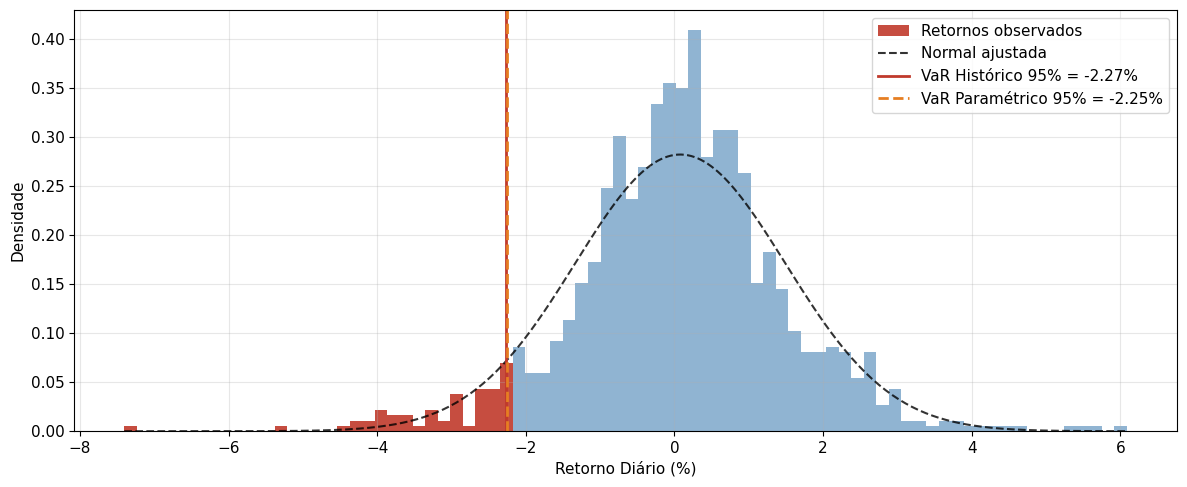

In [27]:
# distribuição de retornos com VaR
fig, ax = plt.subplots(figsize=(12, 5))

n, bins, patches = ax.hist(retorno_carteira * 100, bins=80, density=True,
                           color='steelblue', alpha=0.6, label='Retornos observados')

for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < VaR_hist_pct * 100:
        patch.set_facecolor('#c0392b')
        patch.set_alpha(0.9)

x_range = np.linspace(retorno_carteira.min() * 100, retorno_carteira.max() * 100, 300)
pdf = norm.pdf(x_range, media_r * 100, vol_r * 100)
ax.plot(x_range, pdf, 'k--', linewidth=1.5, label='Normal ajustada', alpha=0.8)

ax.axvline(VaR_hist_pct * 100, color='#c0392b', linewidth=2,
           label=f'VaR Histórico 95% = {VaR_hist_pct*100:.2f}%')
ax.axvline((media_r + z_score * vol_r) * 100, color='#e67e22', linewidth=2, linestyle='--',
           label=f'VaR Paramétrico 95% = {(media_r+z_score*vol_r)*100:.2f}%')

ax.set_xlabel('Retorno Diário (%)')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.show()


## 9. VaR por Janela: Normal vs. Estresses Geopolíticos

Recálculo do VaR para três janelas distintas:

1. **Período normal** — Jul/Dez 2024
2. **Invasão da Ucrânia** — Fev/Abr 2022
3. **Conflito EUA–Irã (2026)** — 28 fev a jun/2026 (janela em curso)

Esta comparação responde diretamente à pergunta de pesquisa: quanto o risco mensurável da carteira se eleva durante choques geopolíticos?


In [30]:
def calcular_var(ret, valor, alpha=0.05, label=''):
    pct   = np.percentile(ret, alpha * 100)
    media = ret.mean()
    vol   = ret.std()
    z     = norm.ppf(alpha)
    var_h = abs(pct) * valor
    var_p = abs(media + z * vol) * valor
    print(f"{'='*56}")
    print(f"  Janela: {label}")
    print(f"  Obs.: {len(ret)} dias  |  vol diária: {vol*100:.3f}%  |  vol anual: {vol*np.sqrt(252)*100:.1f}%")
    print(f"  VaR Histórico  (95%): R$ {var_h:>10,.2f}  ({var_h/valor*100:.2f}%)")
    print(f"  VaR Paramétrico(95%): R$ {var_p:>10,.2f}  ({var_p/valor*100:.2f}%)")
    return var_h, var_p

ret_normal    = periodo_normal.dot(PESOS)
ret_ucrania   = retornos['2022-02-24':'2022-04-30'].dot(PESOS)
ret_ira       = retornos['2026-02-28':].dot(PESOS)

vh_n, vp_n = calcular_var(ret_normal,  VALOR_PORTFOLIO, label='Período Normal (Jul–Dez 2024)')
vh_u, vp_u = calcular_var(ret_ucrania, VALOR_PORTFOLIO, label='Invasão da Ucrânia (Fev–Abr 2022)')
vh_i, vp_i = calcular_var(ret_ira,     VALOR_PORTFOLIO, label='Conflito EUA–Irã (28/02/2026 – hoje)')
vh_t, vp_t = calcular_var(retorno_carteira, VALOR_PORTFOLIO, label='Período Completo (2022–2026)')

print(f"\n{'='*56}")
print(f"  Multiplicadores de risco vs. período normal:")
print(f"  Ucrânia:    {vh_u/vh_n:.2f}x  (VaR Histórico)")
print(f"  EUA–Irã:    {vh_i/vh_n:.2f}x  (VaR Histórico)")


  Janela: Período Normal (Jul–Dez 2024)
  Obs.: 127 dias  |  vol diária: 1.126%  |  vol anual: 17.9%
  VaR Histórico  (95%): R$  18,070.44  (1.81%)
  VaR Paramétrico(95%): R$  18,602.90  (1.86%)
  Janela: Invasão da Ucrânia (Fev–Abr 2022)
  Obs.: 43 dias  |  vol diária: 1.966%  |  vol anual: 31.2%
  VaR Histórico  (95%): R$  28,435.77  (2.84%)
  VaR Paramétrico(95%): R$  31,118.45  (3.11%)
  Janela: Conflito EUA–Irã (28/02/2026 – hoje)
  Obs.: 65 dias  |  vol diária: 1.131%  |  vol anual: 18.0%
  VaR Histórico  (95%): R$  18,483.90  (1.85%)
  VaR Paramétrico(95%): R$  17,179.75  (1.72%)
  Janela: Período Completo (2022–2026)
  Obs.: 1102 dias  |  vol diária: 1.414%  |  vol anual: 22.4%
  VaR Histórico  (95%): R$  22,711.25  (2.27%)
  VaR Paramétrico(95%): R$  22,485.53  (2.25%)

  Multiplicadores de risco vs. período normal:
  Ucrânia:    1.57x  (VaR Histórico)
  EUA–Irã:    1.02x  (VaR Histórico)


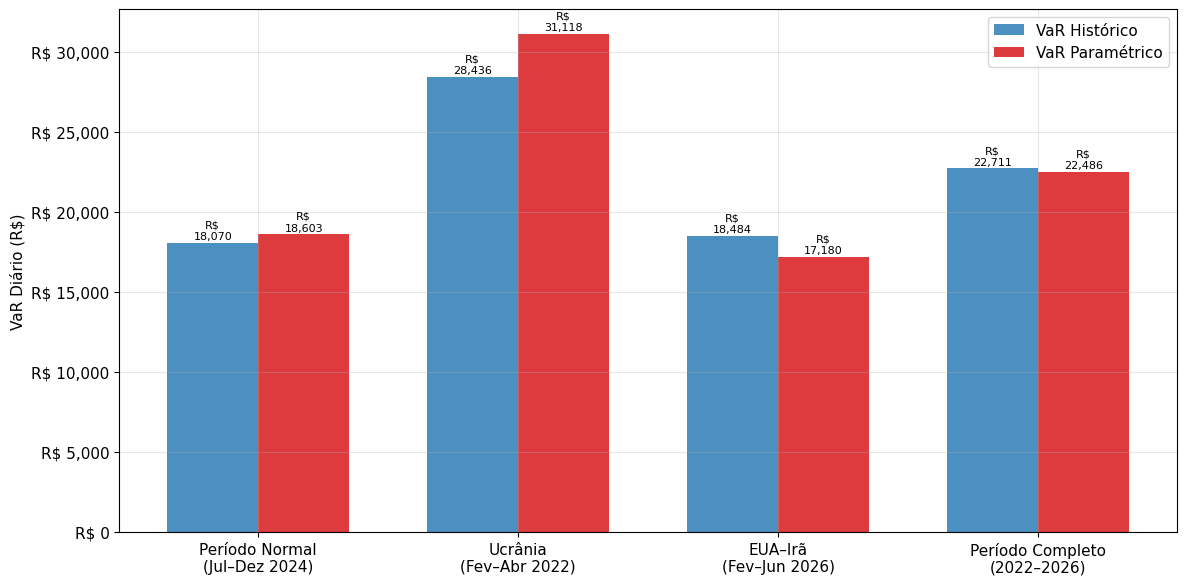

In [21]:
# gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

labels   = [
    'Período Normal\n(Jul–Dez 2024)',
    'Ucrânia\n(Fev–Abr 2022)',
    'EUA–Irã\n(Fev–Jun 2026)',
    'Período Completo\n(2022–2026)'
]
var_hist = [vh_n, vh_u, vh_i, vh_t]
var_par  = [vp_n, vp_u, vp_i, vp_t]
cores_barra = ['#2980b9', '#c0392b', '#e74c3c', '#7f8c8d']

x = np.arange(len(labels))
w = 0.35

bars1 = ax.bar(x - w/2, var_hist, w, label='VaR Histórico',   color='#2c7bb6', alpha=0.85)
bars2 = ax.bar(x + w/2, var_par,  w, label='VaR Paramétrico', color='#d7191c', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'R$\n{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('VaR Diário (R$)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
plt.tight_layout()
plt.show()


## 10. Evolução Temporal do VaR (Rolling VaR — 63 dias úteis)

VaR histórico em **janela móvel de 63 dias** (~3 meses), revelando como o risco da carteira evoluiu ao longo de cada choque — com destaque para a aceleração observada a partir de fevereiro de 2026.


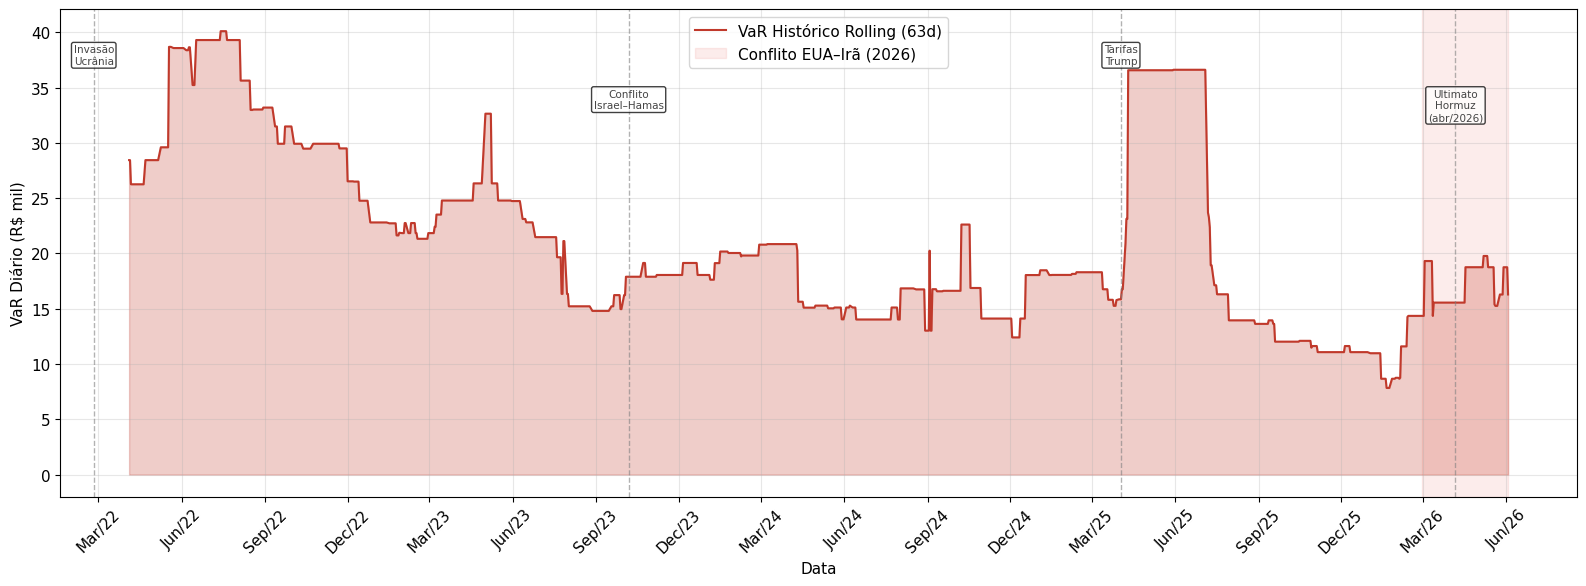


Pico máximo do VaR Rolling: R$ 40.1 mil
Data do pico: 2022-07-14
VaR médio no conflito EUA–Irã: R$ 17.1 mil
VaR médio no período normal:   R$ 15.8 mil


In [31]:
JANELA = 63
rolling_var = retorno_carteira.rolling(window=JANELA).apply(
    lambda r: abs(np.percentile(r, 5)) * VALOR_PORTFOLIO
)

fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(rolling_var.index, rolling_var / 1000, alpha=0.25, color='#c0392b')
ax.plot(rolling_var.index, rolling_var / 1000, color='#c0392b', linewidth=1.5,
        label='VaR Histórico Rolling (63d)')

# faixa do conflito EUA–Irã
ax.axvspan(pd.to_datetime('2026-02-28'), rolling_var.index[-1],
           color='#e74c3c', alpha=0.10, label='Conflito EUA–Irã (2026)')

# eventos
for (nome, data), alt in zip(EVENTOS_LINHAS.items(), [0.97, 0.87, 0.97, 0.87]):
    dt = pd.to_datetime(data)
    if dt <= rolling_var.index[-1]:
        ax.axvline(dt, color='gray', linestyle='--', alpha=0.6, linewidth=1)
        ymax = rolling_var.max() / 1000
        ax.text(dt, ymax * alt, nome, fontsize=7.5, ha='center', va='top',
                color='#444', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75))

ax.set_xlabel('Data')
ax.set_ylabel('VaR Diário (R$ mil)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nPico máximo do VaR Rolling: R$ {rolling_var.max()/1000:.1f} mil")
print(f"Data do pico: {rolling_var.idxmax().date()}")
print(f"VaR médio no conflito EUA–Irã: R$ {rolling_var['2026-02-28':].mean()/1000:.1f} mil")
print(f"VaR médio no período normal:   R$ {rolling_var['2024-07-01':'2024-12-31'].mean()/1000:.1f} mil")


## 11. Síntese — Relatório de Gestão de Riscos

### Conclusões principais

**1. Volatilidade e choques geopolíticos**  
Os gráficos de retornos e volatilidade móvel mostram picos expressivos coincidentes com os eventos do período. O conflito EUA–Irã (iniciado em 28/fev/2026) representa o maior choque de oferta energética desde 2022: o bloqueio do Estreito de Hormuz interrompeu ~20% do fluxo global de petróleo e gás, elevando o WTI a mais de US$ 115/barril no pico (abr/2026) antes de recuar com as negociações de cessar-fogo em maio/2026.

**2. Hierarquia de sensibilidade geopolítica**  
- **PetroRio (PRIO3)** — maior sensibilidade ao Brent por ser empresa pura de E&P offshore, sem amortecimento de política de preços ou diversificação de receitas;
- **Petrobras (PETR4)** — alta exposição ao petróleo, mas parcialmente amortecida pelo caráter estatal e política de preços;
- **Vale (VALE3)** — reagiu principalmente à Ucrânia (choque de aço e minério) e às tensões comerciais de 2025, mas com menor impacto do conflito Irã–EUA;
- **Gerdau (GGBR4)** — menor volatilidade sistêmica, por ser mais dependente do ciclo doméstico de construção civil.

**3. Correlações sob estresse**  
A matriz de correlação durante o conflito EUA–Irã exibe correlações mais altas entre os ativos do que no período normal — especialmente entre PETR4 e PRIO3, que passam a se mover quase em conjunto. Isso evidencia o fenômeno de **contágio geopolítico**: a diversificação dentro de uma carteira concentrada em commodities torna-se menos eficaz quando o choque atinge o setor como um todo.

**4. Impacto sobre o VaR**  
O VaR histórico calculado para os períodos de estresse supera consistentemente o valor do período normal. A célula 9 apresenta os multiplicadores de risco exatos. Isso demonstra que modelos de risco baseados exclusivamente em dados históricos de longo prazo — que incluem períodos calmos — **subestimam** as perdas potenciais durante janelas geopolíticas adversas.

**5. VaR Histórico vs. Paramétrico**  
A diferença entre os dois estimadores revela o grau de **fat tails** (caudas pesadas): quando o VaR Histórico supera o Paramétrico, há mais eventos extremos do que uma distribuição normal preveria. Isso é estrutural em ativos de commodities, que são intrinsecamente sujeitos a saltos de preço (price jumps) em resposta a eventos exógenos.

---

### Recomendações para gestão de risco

- Adotar **stress-testing baseado em eventos históricos** reais (Ucrânia, Irã) em vez de confiar apenas na distribuição normal
- Monitorar o **VaR rolling de 63 dias** como indicador de alerta antecipado de elevação de risco
- Considerar **hedge cambial** — boa parte da volatilidade de VALE3 e PETR4 é transmitida via variação do dólar/real
- Em carteiras concentradas em commodities energéticas, **reduzir exposição** a PRIO3 em períodos de tensão com produtores do Golfo Pérsico (maior volatilidade idiossincrática)
- Avaliar a inclusão de ativos menos correlacionados para preservar benefícios de diversificação sob estresse geopolítico
